In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


from utils import *
from utils_ice_th import *

# Implémentation modèle théorique

In [2]:
#ds1 = xr.open_dataset('data/data_snow/data_0.nc').load()
#ds2 = xr.open_dataset('data/data_snow/data_0.nc').load()
ds3 = load_climatology_with_deptho()
ds4 = xr.open_dataset('data/era5_1.nc').load()
ds5 = xr.open_dataset('data/era5_1.nc').load()

#ds4 = xr.open_dataset('data/data_snow/data_rad.nc').load()

ds = xr.merge([ds3, ds4, ds5])
ds

<xarray.Dataset> Size: 3GB
Dimensions:     (depth: 39, latitude: 121, longitude: 1440, month: 12,
                 valid_time: 252)
Coordinates:
  * depth       (depth) float32 156B 0.5058 1.556 2.668 ... 370.7 411.8 457.6
  * latitude    (latitude) float64 968B 60.0 60.25 60.5 ... 89.5 89.75 90.0
  * longitude   (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * valid_time  (valid_time) datetime64[ns] 2kB 2003-01-01 ... 2023-12-01
    number      int64 8B 0
    expver      (valid_time) <U4 4kB '0001' '0001' '0001' ... '0001' '0001'
Data variables: (12/18)
    S           (month, depth, latitude, longitude) float32 326MB 32.93 ... 3...
    T           (month, depth, latitude, longitude) float32 326MB 2.22 ... 0....
    SIC         (month, latitude, longitude) float32 8MB 0.0008339 ... 0.982
    SIT         (month, latitude, longitude) float32 8MB 0.002912 ... 1.954
    U           (month, depth, latitude, longitude) float32 326MB -0.04629 .....
    V           (month, depth, latitude, longitude) float32 326MB 0.06839 ......
    ...          ...
    msl         (valid_time, latitude, longitude) float32 176MB 1.003e+05 ......
    u10         (valid_time, latitude, longitude) float32 176MB -5.048 ... 0....
    v10         (valid_time, latitude, longitude) float32 176MB -5.062 ... -0...
    t2m         (valid_time, latitude, longitude) float32 176MB 270.6 ... 252.7
    tsn         (valid_time, latitude, longitude) float32 176MB 276.1 ... 252.8
    tcsw        (valid_time, latitude, longitude) float32 176MB 0.03464 ... 0...
Attributes:
    history:      Creation 2023-October-31 12:55:11 GMT+0200
    source:       Copernicus Marine Service
    title:        Monthly mean fields for product GLOBAL_MULTIYEAR_PHY_ENS_00...
    references:   http://marine.copernicus.eu
    Conventions:  CF-1.6
    institution:  Mercator Ocean
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    contact:      servicedesk.cmems@mercator-ocean.eu

[-24.510143   -24.547861   -22.152037   -14.359195    -5.2602887
   0.27482677   0.69367474   0.80254984  -0.20073155  -5.93118
 -16.703299   -23.334621  ]
[-24.383934   -24.551395   -22.321493   -14.759956    -5.544794
   0.31137812   0.56253636   0.3598415   -0.8121527   -6.8010645
 -17.00994    -23.272678  ]
[-2.4146490e+01 -2.4461643e+01 -2.2330980e+01 -1.4990890e+01
 -5.7122979e+00  3.3946592e-01  5.0756979e-01  3.0706497e-03
 -1.4943514e+00 -7.7027574e+00 -1.7205809e+01 -2.3028910e+01]
[-23.900862   -24.387424   -22.40213    -15.165462    -5.8538527
   0.3486735    0.5773243   -0.20051938  -2.225006    -8.461779
 -17.4586     -22.902515  ]
[-23.644444   -24.19453    -22.53857    -15.286741    -5.9890833
   0.372111     0.6536822   -0.22060867  -2.9696116   -9.354636
 -17.760311   -22.840294  ]
[-23.576736   -24.168024   -22.755552   -15.414439    -6.168585
   0.34672037   0.6498689   -0.2713899   -3.565594   -10.272605
 -18.04528    -22.76719   ]
[-23.620914   -24.312555   -22.89

Text(0.5, 1.0, 'Epaisseur de glace modélisée VS épaisseur observée')

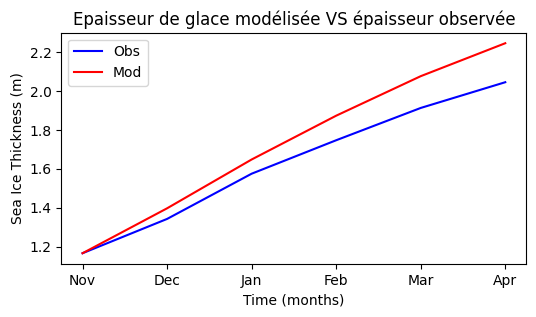

In [19]:
lons = ds.longitude
lats = ds.latitude  

lats = lats.values
lons = lons.values

mois = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mois_depart = 10 #0 pour janvier, 11 pour decembre

permut_mois = permutation_circ_mois(mois, 0, mois_depart)

yobs_a_moy = np.zeros([10,12])
ymod_a_moy = np.zeros([10,12])

for i in range(10) :
    lat = i + 77
    coord1, coord2 = choose_coords(lat, 150, lats, lons)
    yobs_a_moy[i], ymod_a_moy[i] = y_obsVSmod(ds, mois_depart, coord1, coord2)

y_obs = np.nanmean(yobs_a_moy, 0)
y_mod = np.nanmean(ymod_a_moy, 0)

plt.figure(figsize=(6,3))

start = 0
end = 6

plt.plot(permut_mois[start:end], y_obs[start:end], c = 'b', label = 'Obs')#, linestyle = ',')
plt.plot(permut_mois[start:end], y_mod[start:end], c = 'r', label = 'Mod')#, linestyle = ',')

plt.xlabel('Time (months)')
plt.ylabel('Sea Ice Thickness (m)')
plt.legend()
plt.title('Epaisseur de glace modélisée VS épaisseur observée')